# 📘 Module 4.1 — The Attention Mechanism

**Goal:** Understand self-attention — the core innovation behind Transformers, LLMs, and modern ADAS models.

## Why Attention?
- **RNNs** process sequences step-by-step → slow, struggles with long sequences
- **Attention** lets the model look at ALL positions simultaneously → parallelizable, captures long-range dependencies

### The Big Idea
Instead of reading a sequence word-by-word, attention lets the model **focus on the most relevant parts** of the input — like how you focus on the car ahead while driving, not every pixel.

---

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

## 1. Scaled Dot-Product Attention

The fundamental attention operation:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

Where:
- **Q** (Query): "What am I looking for?"
- **K** (Key): "What do I contain?"
- **V** (Value): "What information do I hold?"
- **d_k**: Dimension of keys (for scaling)

### Analogy: Library Search
- **Query:** Your search term
- **Key:** Book titles/tags
- **Value:** Book contents
- **Attention scores:** How relevant each book is to your search

In [2]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Scaled Dot-Product Attention — implemented from scratch.
    
    Args:
        Q: Queries (batch, seq_len_q, d_k)
        K: Keys    (batch, seq_len_k, d_k)
        V: Values  (batch, seq_len_k, d_v)
        mask: Optional attention mask
    
    Returns:
        output: Attended values
        attention_weights: Attention score matrix
    """
    d_k = Q.size(-1)
    
    # Step 1: Compute attention scores
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    
    # Step 2: Apply mask (optional, used in decoder)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))
    
    # Step 3: Softmax to get probabilities
    attention_weights = F.softmax(scores, dim=-1)
    
    # Step 4: Weighted sum of values
    output = torch.matmul(attention_weights, V)
    
    return output, attention_weights

# Example
batch_size = 1
seq_len = 5
d_model = 8

Q = torch.randn(batch_size, seq_len, d_model)
K = torch.randn(batch_size, seq_len, d_model)
V = torch.randn(batch_size, seq_len, d_model)

output, attn_weights = scaled_dot_product_attention(Q, K, V)

print(f"Query shape:     {Q.shape}")
print(f"Output shape:    {output.shape}")
print(f"Attention shape: {attn_weights.shape}")
print(f"\nAttention weights (each row sums to 1.0):")
print(attn_weights.squeeze().detach().numpy().round(3))
print(f"Row sums: {attn_weights.squeeze().sum(dim=-1).detach().numpy().round(3)}")

Query shape:     torch.Size([1, 5, 8])
Output shape:    torch.Size([1, 5, 8])
Attention shape: torch.Size([1, 5, 5])

Attention weights (each row sums to 1.0):
[[0.09  0.074 0.623 0.134 0.079]
 [0.331 0.139 0.057 0.137 0.335]
 [0.092 0.081 0.686 0.027 0.115]
 [0.054 0.797 0.07  0.062 0.017]
 [0.374 0.16  0.152 0.141 0.174]]
Row sums: [1. 1. 1. 1. 1.]


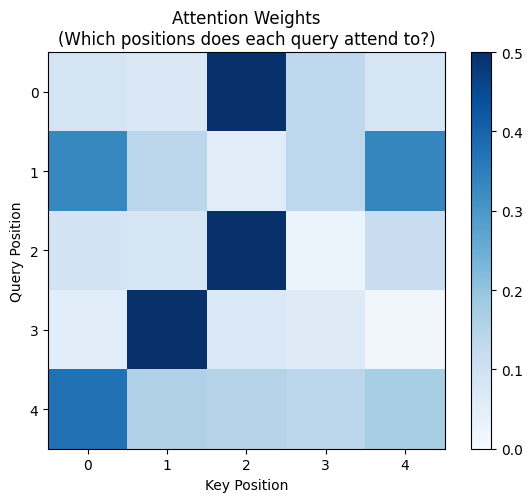

In [3]:
# --- Visualize Attention Weights ---
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(attn_weights.squeeze().detach().numpy(), cmap='Blues', vmin=0, vmax=0.5)
ax.set_xlabel('Key Position')
ax.set_ylabel('Query Position')
ax.set_title('Attention Weights\n(Which positions does each query attend to?)')
plt.colorbar(im)
plt.tight_layout()
plt.show()

## 2. Multi-Head Attention

Instead of one attention, use **multiple heads** — each learns to attend to different aspects:
- Head 1 might focus on **nearby objects**
- Head 2 might focus on **color/texture**
- Head 3 might focus on **motion direction**

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, ..., \text{head}_h)W^O$$

In [4]:
class MultiHeadAttention(nn.Module):
    """Multi-Head Attention — implemented from scratch."""
    
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # Dimension per head
        
        # Linear projections for Q, K, V
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)  # Output projection
    
    def forward(self, Q, K, V, mask=None):
        batch_size = Q.size(0)
        
        # 1. Project Q, K, V
        Q = self.W_q(Q)  # (batch, seq, d_model)
        K = self.W_k(K)
        V = self.W_v(V)
        
        # 2. Reshape to (batch, num_heads, seq, d_k)
        Q = Q.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        
        # 3. Apply attention (per head)
        output, attn_weights = scaled_dot_product_attention(Q, K, V, mask)
        
        # 4. Concatenate heads
        output = output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        
        # 5. Output projection
        output = self.W_o(output)
        
        return output, attn_weights

# Test
mha = MultiHeadAttention(d_model=64, num_heads=8)
x = torch.randn(2, 10, 64)  # batch=2, seq=10, d_model=64
out, weights = mha(x, x, x)  # Self-attention: Q=K=V=x

print(f"Input:    {x.shape}")
print(f"Output:   {out.shape}")
print(f"Weights:  {weights.shape}  (batch, heads, seq_q, seq_k)")

Input:    torch.Size([2, 10, 64])
Output:   torch.Size([2, 10, 64])
Weights:  torch.Size([2, 8, 10, 10])  (batch, heads, seq_q, seq_k)


## 3. Positional Encoding

Attention has **no notion of position** — "cat sat mat" = "mat sat cat". We add positional encodings to give position information.

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d}}\right)$$

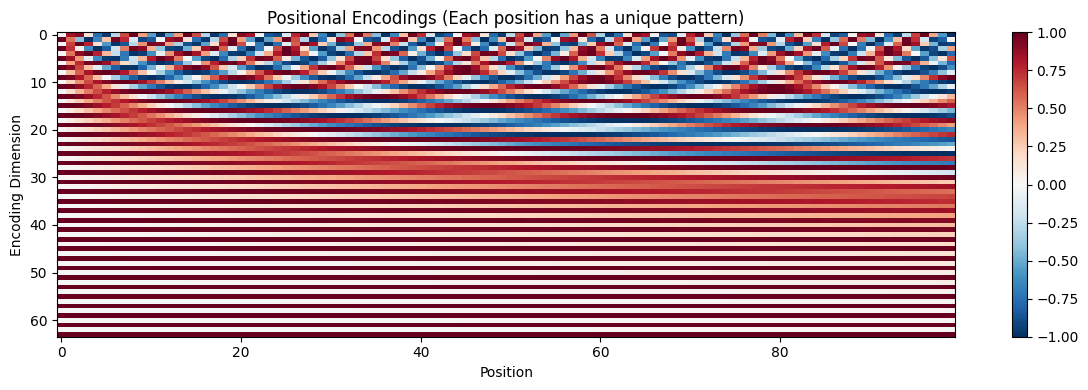

In [5]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding."""
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)  # Even indices
        pe[:, 1::2] = torch.cos(position * div_term)  # Odd indices
        
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

# Visualize positional encodings
pe = PositionalEncoding(d_model=64)
encodings = pe.pe.squeeze().numpy()[:100, :]

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(encodings.T, aspect='auto', cmap='RdBu_r')
ax.set_xlabel('Position')
ax.set_ylabel('Encoding Dimension')
ax.set_title('Positional Encodings (Each position has a unique pattern)')
plt.colorbar(im)
plt.tight_layout()
plt.show()

## 4. The Complete Transformer Block

```
Input
  │
  ├──► Multi-Head Attention ──► Add & LayerNorm
  │         (self-attention)            │
  │                                     │
  └─────────────────────────────────────┘ (Residual)
                                        │
  ├──► Feed-Forward Network ──► Add & LayerNorm
  │     (2-layer MLP)                   │
  │                                     │
  └─────────────────────────────────────┘ (Residual)
                                        │
                                     Output
```

In [6]:
class TransformerBlock(nn.Module):
    """A single Transformer encoder block."""
    
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        
        # Multi-Head Self-Attention
        self.attention = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        
        # Feed-Forward Network
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),  # Modern activation (better than ReLU for transformers)
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, mask=None):
        # Self-Attention with residual connection
        attn_out, _ = self.attention(x, x, x, attn_mask=mask)
        x = self.norm1(x + self.dropout(attn_out))  # Residual + LayerNorm
        
        # Feed-Forward with residual connection
        ffn_out = self.ffn(x)
        x = self.norm2(x + ffn_out)  # Residual + LayerNorm
        
        return x

# Test
block = TransformerBlock(d_model=256, num_heads=8, d_ff=1024)
x = torch.randn(4, 50, 256)  # batch=4, seq=50, d_model=256
out = block(x)
print(f"Transformer Block: {x.shape} → {out.shape}")
print(f"Parameters: {sum(p.numel() for p in block.parameters()):,}")

Transformer Block: torch.Size([4, 50, 256]) → torch.Size([4, 50, 256])


Parameters: 789,760


---
## ✅ Key Takeaways

1. **Attention** lets models focus on relevant parts of the input (not sequential processing)
2. **Q, K, V** = Query (what I seek), Key (what I have), Value (what I give)
3. **Multi-head attention** = multiple parallel attention operations (learn different patterns)
4. **Positional encoding** adds position information (since attention has no order)
5. **Transformer block** = Attention + FFN + Residual connections + LayerNorm

---
## 📖 Next Steps
➡️ **Next notebook:** [02_vision_transformer_vit.ipynb](02_vision_transformer_vit.ipynb) — Vision Transformers for image understanding